In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [54]:
df = pd.read_csv("data/MICRODADOS_ENEM_2020.csv", encoding="cp860", sep=";")

In [60]:
df = df.sample(2_000_000, random_state=42)
# I will consider the score in portuguese test
df["target"] = df["NU_NOTA_LC"]
df["TP_DEPENDENCIA_ADM_ESC"] = df["TP_DEPENDENCIA_ADM_ESC"].fillna(-1)

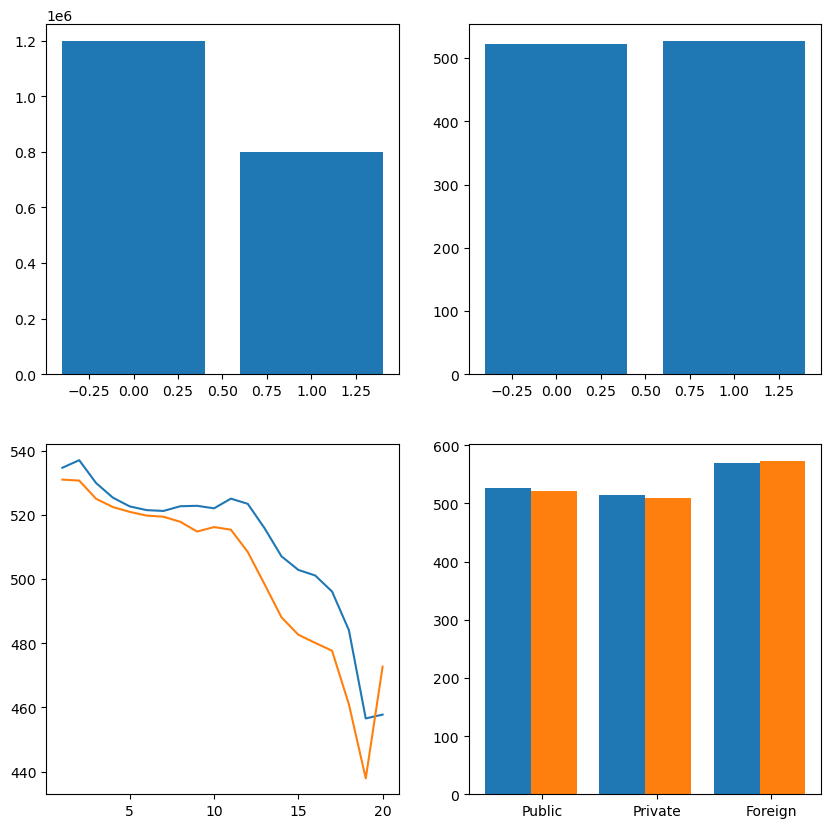

In [62]:

fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (10, 10))

axs[0, 0].bar(
    [0, 1],
    df["TP_SEXO"].value_counts().values,
)


axs[0, 1].bar(
    [0, 1],
    df.groupby("TP_SEXO")["target"].mean().values
)


def simplify_age(age):
    return age // 4 * 4

#df["age"] = df["NU_IDADE"].apply(simplify_age)

for i in ["M", "F"]:
    df_filter = df[df["TP_SEXO"] == i]
    df_filter = df_filter.groupby("TP_FAIXA_ETARIA")["target"].mean().reset_index()
    axs[1, 0].plot(
        df_filter["TP_FAIXA_ETARIA"],
        df_filter["target"],
    )


#df["COMBINED_SCHOOL"] = df["TP_ESCOLA"] * 10000 # + df["TP_DEPENDENCIA_ADM_ESC"]
df["COMBINED_SCHOOL"] = df["TP_ESCOLA"]

labels_school = ["Public", "Private", "Foreign"]
for i, g in enumerate(["M", "F"]):
    df_filter = df[df["TP_SEXO"] == g]
    unique_schools = df_filter["COMBINED_SCHOOL"].unique()
    axs[1, 1].bar(
        np.arange(len(unique_schools)) + i * 0.4 + 0.1,
        df_filter.groupby("COMBINED_SCHOOL")["target"].mean().values,
        width=0.4,
    )
axs[1, 1].set_xticks(np.arange(len(unique_schools)) + 0.4)
axs[1, 1].set_xticklabels(labels_school)

plt.show()


In [63]:
score_threshold = 500
# for each type of school
for school in sorted(df["COMBINED_SCHOOL"].unique()):
    # for each age category
    for age in sorted(df["TP_FAIXA_ETARIA"].unique()):
        df_filter = df[(df["COMBINED_SCHOOL"] == school) & (df["TP_FAIXA_ETARIA"] == age)]
        y = df_filter["target"].values > score_threshold
        print(school, age, y.mean())


1 1 0.49958684064761594
1 2 0.4686091120383075
1 3 0.41437355437207274
1 4 0.3644719887095785
1 5 0.30401436720895836
1 6 0.26919579056775367
1 7 0.24422319880483737
1 8 0.22897765404787354
1 9 0.21236144648415908
1 10 0.198837949164462
1 11 0.1903681174188037
1 12 0.18172985165264163
1 13 0.17071451941710922
1 14 0.16315887118385522
1 15 0.1619887730553328
1 16 0.1583596214511041
1 17 0.16060806345009915
1 18 0.14085014409221902
1 19 0.08705114254624592
1 20 0.10855263157894737
2 1 0.45056320400500627
2 2 0.44623879163801045
2 3 0.36044420355017925
2 4 0.22292146782485375
2 5 0.149430884411711
2 6 0.1011008111239861
2 7 0.07809523809523809
2 8 0.07400232468035645
2 9 0.0621414913957935
2 10 0.07076923076923076
2 11 0.06785567855678556
2 12 0.045576407506702415
2 13 0.05631244323342416
2 14 0.06463878326996197
2 15 0.058165548098434
2 16 0.05652173913043478
2 17 0.05263157894736842
2 18 0.05813953488372093
2 19 0.037037037037037035
2 20 0.0
3 1 0.7563722584469472
3 2 0.754564379890407


/tmp/ipykernel_2132/1916839983.py:8: RuntimeWarning: Mean of empty slice.
  print(school, age, y.mean())
/work/giovani.valdrighi/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
